In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

Forecasting Model for HDAM - Kastraki plant

In [ ]:
# Load the weather CSV file into a DataFrame
weather_HDAM_df = pd.read_csv("../data/weather_HDAM.csv")

In [7]:
# Load the generation CSV file into separate DataFrames
generation_HDAM_2022_df = pd.read_csv("../data/timeseries_2022.csv")
generation_HDAM_2023_df = pd.read_csv("../data/timeseries_2023.csv")
generation_HDAM_2024_df = pd.read_csv("../data/timeseries_2024.csv")

In [15]:
# Consolidate all generation DataFrames into one
generation_df = pd.concat([generation_HDAM_2022_df, generation_HDAM_2023_df, generation_HDAM_2024_df], ignore_index=True)

# Filter the consolidated DataFrame to keep only rows where plant_name is "KASTRAKI"
generation_kastraki_df = generation_df[generation_df['plant_name'] == 'KASTRAKI'].copy()  # Explicitly create a copy

# Extract the timestamp from the 'start_time' and 'position' columns
generation_kastraki_df['timestamp'] = pd.to_datetime(generation_kastraki_df['start_time']) + pd.to_timedelta(
    generation_kastraki_df['position'], unit='h'
)

# Format the 'timestamp' column as 'YYYY-MM-DD HH:MM'
generation_kastraki_df['timestamp'] = generation_kastraki_df['timestamp'].dt.strftime('%Y-%m-%d %H:%M')

# Display the first few rows of the updated DataFrame
print(generation_kastraki_df[['start_time', 'position', 'timestamp']].head())

            start_time  position         timestamp
207  2022-01-01T00:00Z         1  2022-01-01 01:00
208  2022-01-01T00:00Z         2  2022-01-01 02:00
209  2022-01-01T00:00Z         3  2022-01-01 03:00
210  2022-01-01T00:00Z         4  2022-01-01 04:00
211  2022-01-01T00:00Z         5  2022-01-01 05:00


In [18]:
# Extract the timestamp from the 'date' column
weather_HDAM_df['timestamp'] = pd.to_datetime(weather_HDAM_df['date'])

# Format the 'timestamp' column as 'YYYY-MM-DD HH:MM'
weather_HDAM_df['timestamp'] = weather_HDAM_df['timestamp'].dt.strftime('%Y-%m-%d %H:%M')

# Display the first few rows of the updated DataFrame
print(weather_HDAM_df[['date', 'timestamp']].head())

                        date         timestamp
0  2021-12-31 21:00:00+00:00  2021-12-31 21:00
1  2021-12-31 22:00:00+00:00  2021-12-31 22:00
2  2021-12-31 23:00:00+00:00  2021-12-31 23:00
3  2022-01-01 00:00:00+00:00  2022-01-01 00:00
4  2022-01-01 01:00:00+00:00  2022-01-01 01:00


In [19]:
weather_HDAM_df.head()

,date,rain,precipitation,precipitation_probability,apparent_temperature,temperature_2m,evapotranspiration,soil_temperature_0cm,showers,snowfall,snow_depth,timestamp
0,2021-12-31 21:00:00+00:00,0.0,0.0,NaN,7.471656,9.3715,NaN,NaN,0.0,0.0,0.0,2021-12-31 21:00
1,2021-12-31 22:00:00+00:00,0.0,0.0,NaN,3.725250,6.0715,NaN,NaN,0.0,0.0,0.0,2021-12-31 22:00
2,2021-12-31 23:00:00+00:00,0.0,0.0,NaN,3.304805,5.6215,NaN,NaN,0.0,0.0,0.0,2021-12-31 23:00
3,2022-01-01 00:00:00+00:00,0.0,0.0,NaN,2.857551,5.6215,NaN,NaN,0.0,0.0,0.0,2022-01-01 00:00
4,2022-01-01 01:00:00+00:00,0.0,0.0,NaN,2.392103,5.1215,NaN,NaN,0.0,0.0,0.0,2022-01-01 01:00


In [22]:
generation_kastraki_df.head()

,plant_name,psr_type,start_time,end_time,position,Generation (MW),timestamp
207,KASTRAKI,Hydro Water Reservoir,2022-01-01T00:00Z,2022-01-01T23:00Z,1,139.0,2022-01-01 01:00
208,KASTRAKI,Hydro Water Reservoir,2022-01-01T00:00Z,2022-01-01T23:00Z,2,70.0,2022-01-01 02:00
209,KASTRAKI,Hydro Water Reservoir,2022-01-01T00:00Z,2022-01-01T23:00Z,3,70.0,2022-01-01 03:00
210,KASTRAKI,Hydro Water Reservoir,2022-01-01T00:00Z,2022-01-01T23:00Z,4,70.0,2022-01-01 04:00
211,KASTRAKI,Hydro Water Reservoir,2022-01-01T00:00Z,2022-01-01T23:00Z,5,76.0,2022-01-01 05:00


In [23]:
# Merge the two DataFrames on the 'timestamp' column using an outer join
combined_df = pd.merge(weather_HDAM_df, generation_kastraki_df, on='timestamp', how='inner')

# Display the first few rows of the combined DataFrame
print(combined_df.head())

                        date  rain  precipitation  precipitation_probability  \
0  2022-01-01 01:00:00+00:00   0.0            0.0                        NaN   
1  2022-01-01 02:00:00+00:00   0.0            0.0                        NaN   
2  2022-01-01 03:00:00+00:00   0.0            0.0                        NaN   
3  2022-01-01 04:00:00+00:00   0.0            0.0                        NaN   
4  2022-01-01 05:00:00+00:00   0.0            0.0                        NaN   

   apparent_temperature  temperature_2m  evapotranspiration  \
0              2.392103          5.1215                 NaN   
1              2.410219          5.0215                 NaN   
2              3.151335          5.4215                 NaN   
3              3.859724          5.9215                 NaN   
4              2.683826          4.9715                 NaN   

   soil_temperature_0cm  showers  snowfall  snow_depth         timestamp  \
0                   NaN      0.0       0.0         0.0  2022-01-

In [24]:
combined_df.columns

Index(['date', 'rain', 'precipitation', 'precipitation_probability',
       'apparent_temperature', 'temperature_2m', 'evapotranspiration',
       'soil_temperature_0cm', 'showers', 'snowfall', 'snow_depth',
       'timestamp', 'plant_name', 'psr_type', 'start_time', 'end_time',
       'position', 'Generation (MW)'],
      dtype='object')

---------------EXPLORATORY DATA ANALYSIS (EDA)---------------

Dropping uneccesary information

In [ ]:
# Drop the specified columns from combined_df
combined_df = combined_df.drop(columns=['start_time', 'end_time', 'position', 'date', 'psr_type', 'plant_name'])

   rain  precipitation  precipitation_probability  apparent_temperature  \
0   0.0            0.0                        NaN              2.392103   
1   0.0            0.0                        NaN              2.410219   
2   0.0            0.0                        NaN              3.151335   
3   0.0            0.0                        NaN              3.859724   
4   0.0            0.0                        NaN              2.683826   

   temperature_2m  evapotranspiration  soil_temperature_0cm  showers  \
0          5.1215                 NaN                   NaN      0.0   
1          5.0215                 NaN                   NaN      0.0   
2          5.4215                 NaN                   NaN      0.0   
3          5.9215                 NaN                   NaN      0.0   
4          4.9715                 NaN                   NaN      0.0   

   snowfall  snow_depth         timestamp  Generation (MW)  
0       0.0         0.0  2022-01-01 01:00            13

In [28]:
# Reorder columns to make 'timestamp' the first column and 'Generation (MW)' the second column
columns = ['timestamp', 'Generation (MW)'] + [col for col in combined_df.columns if col not in ['timestamp', 'Generation (MW)']]
combined_df = combined_df[columns]

In [30]:
# Count the number of rows in combined_df
row_count = combined_df.shape[0]

# Print the row count
print(f"The combined DataFrame has {row_count} rows.")

The combined DataFrame has 24771 rows.


In [31]:
# Check for NaN values in the DataFrame
nan_counts = combined_df.isnull().sum()

# Display the count of NaN values for each column
print("NaN values in each column:")
print(nan_counts)

NaN values in each column:
timestamp                        0
Generation (MW)                  0
rain                             0
precipitation                    0
precipitation_probability    24771
apparent_temperature             0
temperature_2m                   0
evapotranspiration           24771
soil_temperature_0cm         24771
showers                          0
snowfall                         0
snow_depth                     483
dtype: int64


In [32]:
# Drop the specified columns from combined_df
combined_df = combined_df.drop(columns=['precipitation_probability', 'evapotranspiration', 'soil_temperature_0cm'])

# Display the updated DataFrame's columns
print("Updated columns in combined_df:")
print(combined_df.columns)

Updated columns in combined_df:
Index(['timestamp', 'Generation (MW)', 'rain', 'precipitation',
       'apparent_temperature', 'temperature_2m', 'showers', 'snowfall',
       'snow_depth'],
      dtype='object')


In [38]:
# Convert 'timestamp' back to datetime format if it's not already
combined_df['timestamp'] = pd.to_datetime(combined_df['timestamp'])

# Extract the date from the 'timestamp' column
combined_df['date'] = combined_df['timestamp'].dt.date

# Group by 'date' and calculate the sum of 'Generation (MW)'
daily_generation_df = combined_df.groupby('date')['Generation (MW)'].sum().reset_index()

# Display the first few rows of the new DataFrame
print(daily_generation_df.head())

         date  Generation (MW)
0  2022-01-01           4952.0
1  2022-01-02           3547.0
2  2022-01-03           5014.0
3  2022-01-04           5125.0
4  2022-01-05           5103.0


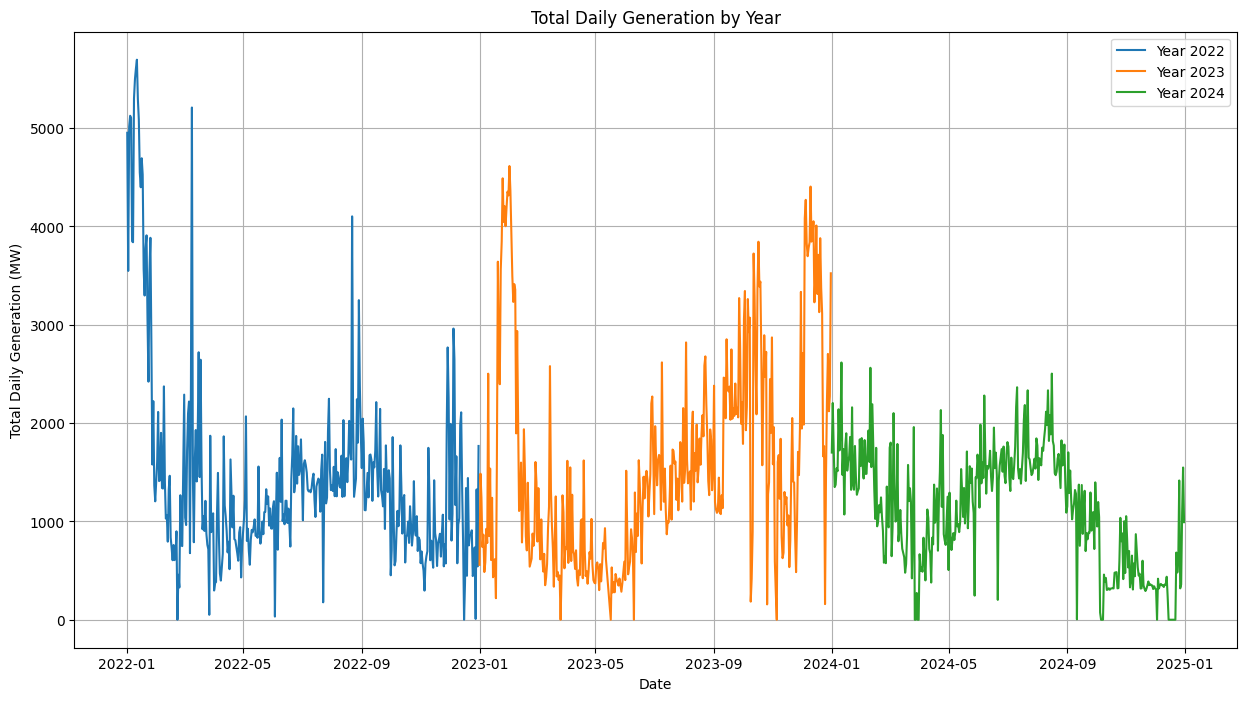

In [ ]:
# Extract the year from the 'date' column
daily_generation_df['year'] = pd.to_datetime(daily_generation_df['date']).dt.year

# Group the data by year
years = daily_generation_df['year'].unique()

# Plot daily generation for each year
plt.figure(figsize=(15, 8))
for year in years:
    yearly_data = daily_generation_df[daily_generation_df['year'] == year]
    plt.plot(yearly_data['date'], yearly_data['Generation (MW)'], label=f'Year {year}')

# Add labels, title, and legend
plt.xlabel('Date')
plt.ylabel('Total Daily Generation (MW)')
plt.title('Total Daily Generation by Year')
plt.legend()
plt.grid(True)
plt.show()

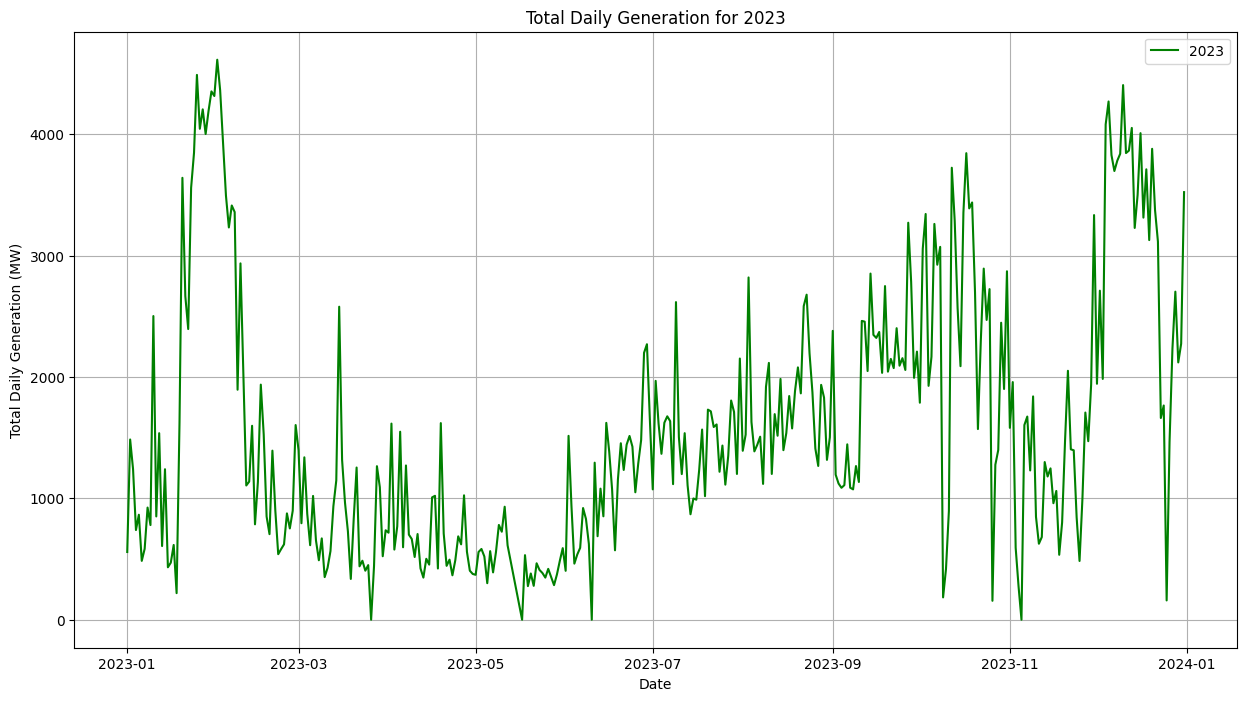

In [ ]:
# Filter the DataFrame for 2023
generation_2023 = daily_generation_df[daily_generation_df['year'] == 2023]

# Plot the daily generation for 2023
plt.figure(figsize=(15, 8))
plt.plot(generation_2023['date'], generation_2023['Generation (MW)'], label='2023', color='green')

# Add labels, title, and legend
plt.xlabel('Date')
plt.ylabel('Total Daily Generation (MW)')
plt.title('Total Daily Generation for 2023')
plt.legend()
plt.grid(True)
plt.show()

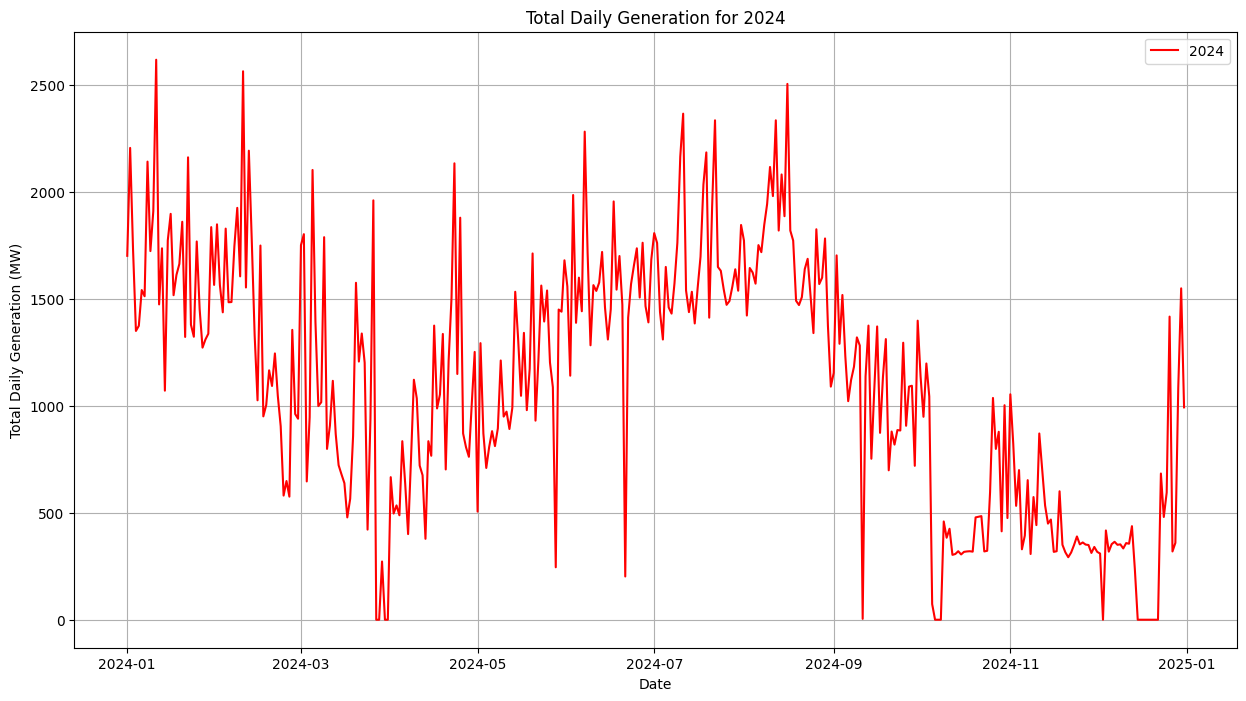

In [46]:
# Filter the DataFrame for 2024
generation_2024 = daily_generation_df[daily_generation_df['year'] == 2024]

# Plot the daily generation for 2024
plt.figure(figsize=(15, 8))
plt.plot(generation_2024['date'], generation_2024['Generation (MW)'], label='2024', color='red')

# Add labels, title, and legend
plt.xlabel('Date')
plt.ylabel('Total Daily Generation (MW)')
plt.title('Total Daily Generation for 2024')
plt.legend()
plt.grid(True)
plt.show()